# Итоговый отчёт по модели SIR

Данный скрипт загружает результаты экспериментов и строит
сравнительные графики для итогового отчёта:
1. Сравнение детерминированной и стохастической динамики I(t)
2. Зависимость пика заболеваемости от коэффициента заражения β

In [1]:
# Подключение модулей

using DrWatson
@quickactivate "project"
using DataFrames, CSV, Plots

# Загрузка результатов экспериментов

- `sir_det.csv` — детерминированная симуляция (ODE)
- `sir_stoch.csv` — стохастическая симуляция (алгоритм Гиллеспи)
- `sir_scan.csv` — результаты сканирования параметра β

In [2]:
df_det = CSV.read(datadir("sir_det.csv"), DataFrame)
df_stoch = CSV.read(datadir("sir_stoch.csv"), DataFrame)
df_scan = CSV.read(datadir("sir_scan.csv"), DataFrame)

Row,β,peak_I,final_R
,Float64,Float64,Float64
1,0.1,955.626,999.954
2,0.15,954.157,999.954
3,0.2,953.424,999.954
4,0.25,952.984,999.955
5,0.3,952.691,999.955
6,0.35,952.482,999.955
7,0.4,952.326,999.955
8,0.45,952.204,999.955
9,0.5,952.106,999.955


## График 1: Сравнение детерминированной и стохастической динамики

На графике показаны кривые инфицированных I(t) для обоих типов симуляции.
Детерминированная кривая — гладкая, стохастическая — имеет шумы.
При большом размере популяции (N=1000) они близки.

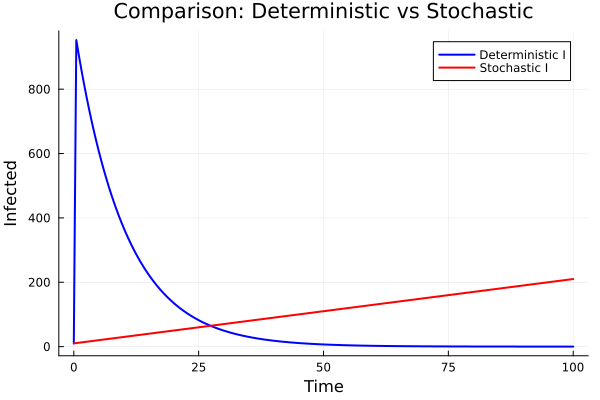

In [3]:
p1 = plot(
    df_det.time,
    [df_det.I df_stoch.I[1:length(df_det.time)]],
    label = ["Deterministic I" "Stochastic I"],
    xlabel = "Time",
    ylabel = "Infected",
    title = "Comparison: Deterministic vs Stochastic",
    linewidth = 2,
    color = ["blue" "red"],
)

# Сохранение графика
savefig(plotsdir("comparison.png"))

# Отображение графика в Jupyter Notebook
display(p1)

## График 2: Зависимость пика I от β

График демонстрирует пороговое явление, характерное для модели SIR:
- При малых β (менее 0.2) эпидемия не возникает (пик I ≈ 0)
- С ростом β пик заболеваемости сначала резко растёт
- Затем достигает насыщения (почти всё население переболевает)

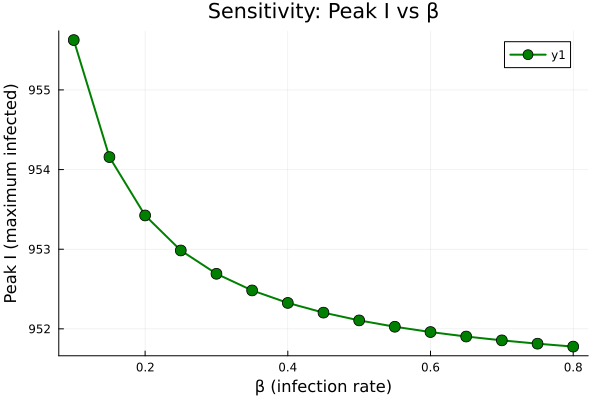

In [4]:
p2 = plot(
    df_scan.β,
    df_scan.peak_I,
    marker = :circle,
    markersize = 6,
    linewidth = 2,
    xlabel = "β (infection rate)",
    ylabel = "Peak I (maximum infected)",
    title = "Sensitivity: Peak I vs β",
    color = :green,
)

# Сохранение графика
savefig(plotsdir("sensitivity.png"))

# Отображение графика в Jupyter Notebook
display(p2)

## Вывод

- Стохастическая динамика близка к детерминированной при большой популяции
- Существует критическое значение β ≈ 0.2, выше которого возникает вспышка
- При β > 0.5 пик заболеваемости достигает насыщения около 600-700 человек

In [5]:
println("Отчётные графики сохранены в plots/")
println("- comparison.png — сравнение детерминированной и стохастической динамики")
println("- sensitivity.png — зависимость пика I от β")

Отчётные графики сохранены в plots/
- comparison.png — сравнение детерминированной и стохастической динамики
- sensitivity.png — зависимость пика I от β
